In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"E:\sales_data\Video Games Data\video_games_cleaned.csv")

In [3]:
df.shape

(16326, 14)

In [4]:
df.head()

,rank,game_name,platform,release_year,genre,publisher,NA_Sales,EU_Sales,JP_Sales,other_sales,global_sales,Decade,main_market,Sales_Category
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,2000s,North Amrica,High
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1980s,North Amrica,High
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.83,2000s,North Amrica,High
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,2000s,North Amrica,High
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.38,1990s,North Amrica,High


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16326 entries, 0 to 16325
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rank            16326 non-null  int64  
 1   game_name       16326 non-null  object 
 2   platform        16326 non-null  object 
 3   release_year    16326 non-null  int64  
 4   genre           16326 non-null  object 
 5   publisher       16290 non-null  object 
 6   NA_Sales        16326 non-null  float64
 7   EU_Sales        16326 non-null  float64
 8   JP_Sales        16326 non-null  float64
 9   other_sales     16326 non-null  float64
 10  global_sales    16326 non-null  float64
 11  Decade          16326 non-null  object 
 12  main_market     16326 non-null  object 
 13  Sales_Category  16326 non-null  object 
dtypes: float64(5), int64(2), object(7)
memory usage: 1.7+ MB


In [6]:
df.isnull().sum()

rank               0
game_name          0
platform           0
release_year       0
genre              0
publisher         36
NA_Sales           0
EU_Sales           0
JP_Sales           0
other_sales        0
global_sales       0
Decade             0
main_market        0
Sales_Category     0
dtype: int64

In [7]:
df["publisher"]=df["publisher"].fillna("Unknown")

In [8]:
df.isnull().sum()

rank              0
game_name         0
platform          0
release_year      0
genre             0
publisher         0
NA_Sales          0
EU_Sales          0
JP_Sales          0
other_sales       0
global_sales      0
Decade            0
main_market       0
Sales_Category    0
dtype: int64

Missing publisher values were replaced with "Unknown" because the records still contain useful sales, platform, genre, and year information.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,rank,release_year,NA_Sales,EU_Sales,JP_Sales,other_sales,global_sales
count,16326.000000,16326.000000,16326.000000,16326.000000,16326.000000,16326.000000,16326.000000
mean,8292.388154,2006.406101,0.265431,0.147563,0.078666,0.048328,0.539988
std,4792.424024,5.828995,0.821613,0.508780,0.311566,0.189891,1.565891
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4136.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8294.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12440.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


### أعلى المنصات مبيعًا

In [11]:
platform_sales=df.groupby("platform")["global_sales"].sum().sort_values(ascending=False)
platform_sales.head(10)

platform
PS2     1233.56
X360     969.31
PS3      949.38
Wii      909.20
DS       817.94
PS       727.56
GBA      312.88
PSP      291.66
PS4      278.16
GB       254.43
Name: global_sales, dtype: float64

### أعلى أنواع الألعاب مبيعًا

In [12]:
genre_sales=df.groupby("genre")["global_sales"].sum().sort_values(ascending=False)
genre_sales.head(10)

genre
Action          1721.86
Sports          1308.83
Shooter         1025.69
Role-Playing     923.75
Platform         828.82
Misc             796.99
Racing           726.54
Fighting         444.08
Simulation       389.88
Puzzle           241.69
Name: global_sales, dtype: float64

### أعلى الشركات الناشرة مبيعًا

In [13]:
publisher_sales=df.groupby("publisher")["global_sales"].sum().sort_values(ascending=False)
publisher_sales.head(10)

publisher
Nintendo                        1784.23
Electronic Arts                 1093.20
Activision                       721.06
Sony Computer Entertainment      607.27
Ubisoft                          473.33
Take-Two Interactive             399.45
THQ                              340.32
Konami Digital Entertainment     278.37
Sega                             270.68
Namco Bandai Games               253.47
Name: global_sales, dtype: float64

### أعلى الألعاب مبيعًا

In [14]:
game_sales=df.groupby("game_name")["global_sales"].sum().sort_values(ascending=False)
game_sales.head(10)

game_name
Wii Sports                        82.74
Grand Theft Auto V                55.92
Super Mario Bros.                 45.31
Tetris                            35.84
Mario Kart Wii                    35.83
Wii Sports Resort                 33.00
Pokemon Red/Pokemon Blue          31.38
Call of Duty: Modern Warfare 3    30.84
New Super Mario Bros.             30.01
Call of Duty: Black Ops II        29.73
Name: global_sales, dtype: float64

### المبيعات حسب السنة

In [15]:
year_sales=df.groupby("release_year")["global_sales"].sum().sort_index()
year_sales.head(10)

release_year
1980    11.38
1981    35.68
1982    28.88
1983    16.80
1984    50.35
1985    53.95
1986    37.08
1987    21.70
1988    47.21
1989    73.45
Name: global_sales, dtype: float64

In [16]:
import matplotlib.pyplot as plt

### رسم أعلى 10 منصات مبيعًا

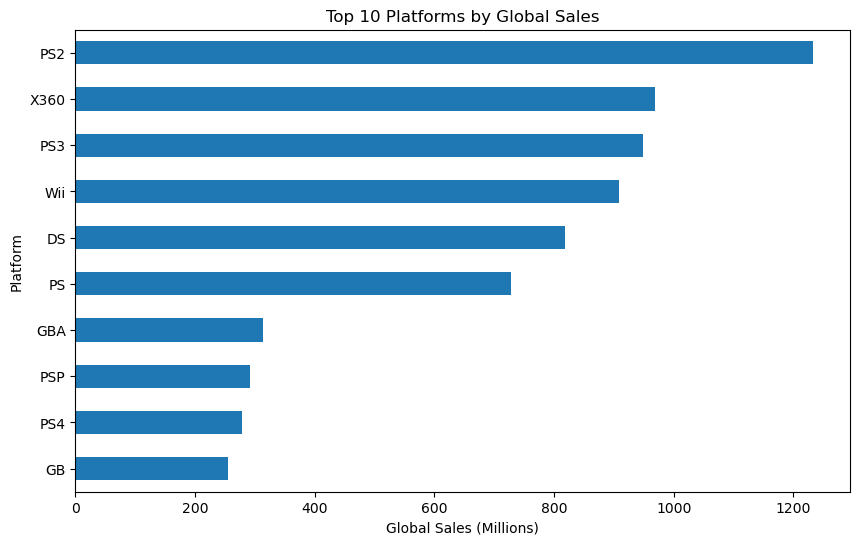

In [17]:
top_platforms=platform_sales.head(10)

plt.figure(figsize=(10,6))
top_platforms.sort_values().plot(kind="barh")
plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Platform")
plt.show()



#### PS2 appears as the highest-selling platform in the dataset, indicating strong historical performance compared to other platforms.

### رسم أعلى أنواع الألعاب مبيعًا

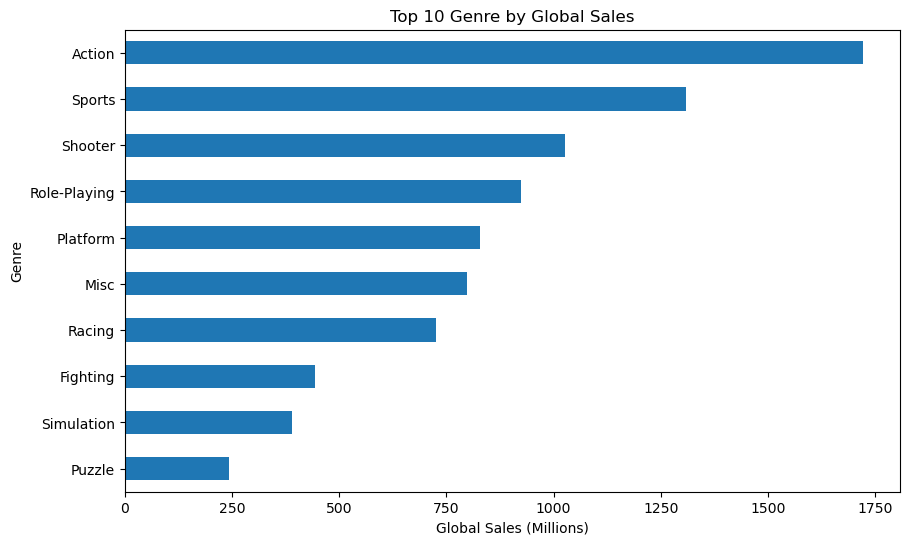

In [18]:
top_genre=genre_sales.head(10)

plt.figure(figsize=(10,6))
top_genre.sort_values().plot(kind="barh")
plt.title("Top 10 Genre by Global Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Genre")
plt.show()


#### Action is the best-selling genre globally, followed by other major genres such as Sports and Shooter.

### رسم المبيعات عبر السنوات

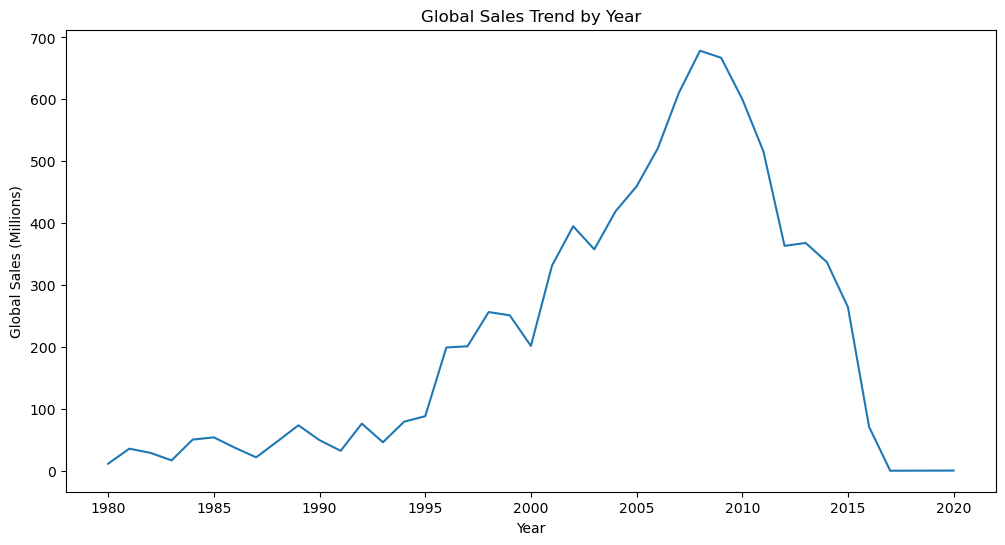

In [19]:
plt.figure(figsize=(12, 6))
year_sales.plot(kind="line")
plt.title("Global Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.show()

#### Global sales increased strongly during the 2000s and peaked around 2008–2009 before declining in later years.

### رسم أعلى 10 شركات ناشرة

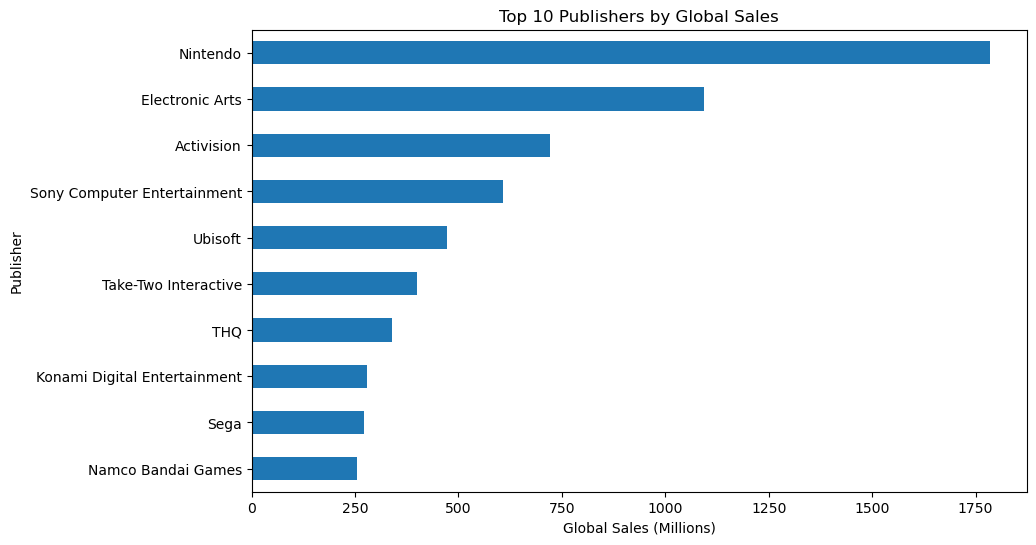

In [20]:
top_publishers = publisher_sales.head(10)

plt.figure(figsize=(10, 6))
top_publishers.sort_values().plot(kind="barh")
plt.title("Top 10 Publishers by Global Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Publisher")
plt.show()


### رسم أعلى 10 ألعاب

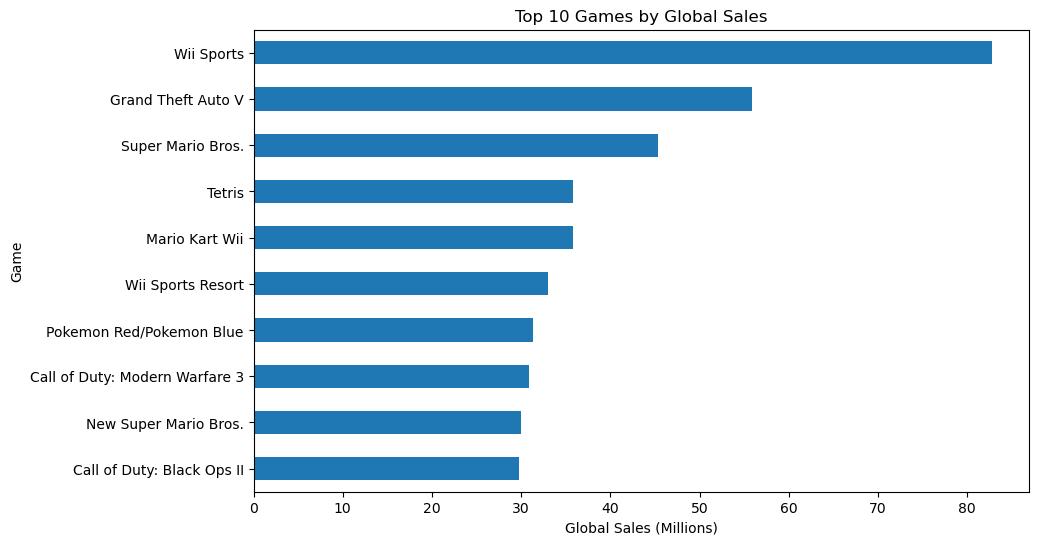

In [21]:
top_games = game_sales.head(10)

plt.figure(figsize=(10, 6))
top_games.sort_values().plot(kind="barh")
plt.title("Top 10 Games by Global Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Game")
plt.show()

In [22]:
top_platforms_df = platform_sales.head(10).reset_index()
top_platforms_df.columns = ["platform", "total_global_sales"]

top_platforms_df

,platform,total_global_sales
0,PS2,1233.56
1,X360,969.31
2,PS3,949.38
3,Wii,909.20
4,DS,817.94
5,PS,727.56
6,GBA,312.88
7,PSP,291.66
8,PS4,278.16
9,GB,254.43


In [23]:
top_genre_df=genre_sales.head(10).reset_index()
top_genre_df.columns=["genre","total_global_sales"]

top_genre_df

,genre,total_global_sales
0,Action,1721.86
1,Sports,1308.83
2,Shooter,1025.69
3,Role-Playing,923.75
4,Platform,828.82
5,Misc,796.99
6,Racing,726.54
7,Fighting,444.08
8,Simulation,389.88
9,Puzzle,241.69


In [24]:
top_publisher_df=publisher_sales.head(10).reset_index()
top_publisher_df.columns=["publisher","total_global_sales"]

top_publisher_df

,publisher,total_global_sales
0,Nintendo,1784.23
1,Electronic Arts,1093.20
2,Activision,721.06
3,Sony Computer Entertainment,607.27
4,Ubisoft,473.33
5,Take-Two Interactive,399.45
6,THQ,340.32
7,Konami Digital Entertainment,278.37
8,Sega,270.68
9,Namco Bandai Games,253.47


In [25]:
top_games_df = game_sales.head(10).reset_index()
top_games_df.columns = ["game_name", "total_global_sales"]

top_games_df

,game_name,total_global_sales
0,Wii Sports,82.74
1,Grand Theft Auto V,55.92
2,Super Mario Bros.,45.31
3,Tetris,35.84
4,Mario Kart Wii,35.83
5,Wii Sports Resort,33.00
6,Pokemon Red/Pokemon Blue,31.38
7,Call of Duty: Modern Warfare 3,30.84
8,New Super Mario Bros.,30.01
9,Call of Duty: Black Ops II,29.73


In [26]:
year_sales_df = year_sales.reset_index()
year_sales_df.columns = ["release_year", "total_global_sales"]

year_sales_df.head()

,release_year,total_global_sales
0,1980,11.38
1,1981,35.68
2,1982,28.88
3,1983,16.80
4,1984,50.35


### استخراج أهم القيم تلقائيًا

In [27]:
top_platform = platform_sales.idxmax()
top_platform_sales = platform_sales.max()

top_genre = genre_sales.idxmax()
top_genre_sales = genre_sales.max()

top_publisher = publisher_sales.idxmax()
top_publisher_sales = publisher_sales.max()

top_game = game_sales.idxmax()
top_game_sales = game_sales.max()

In [28]:
print("Top Platform:", top_platform, "-", round(top_platform_sales, 2), "million")
print("Top Genre:", top_genre, "-", round(top_genre_sales, 2), "million")
print("Top Publisher:", top_publisher, "-", round(top_publisher_sales, 2), "million")
print("Top Game:", top_game, "-", round(top_game_sales, 2), "million")

Top Platform: PS2 - 1233.56 million
Top Genre: Action - 1721.86 million
Top Publisher: Nintendo - 1784.23 million
Top Game: Wii Sports - 82.74 million


### أعلى سنة من حيث إجمالي المبيعات.

In [29]:
peak_year=year_sales.idxmax()
peak_year_sales=year_sales.max()

print("Peak Year:",peak_year,"-",round(peak_year_sales,2),"million")

Peak Year: 2008 - 678.49 million


## Key Python Insights

1. PS2 is the highest-selling platform in the dataset.
2. Action is the best-selling genre globally.
3. Nintendo is one of the leading publishers by global sales.
4. Wii Sports is the top-selling game.
5. Global sales peaked around 2008–2009 before declining in later years.